# Hands-On Assignment 5

In this assignment, you will practice everything that you have learned so far in an end-to-end setting.
You will be provided with a dataset that is **unique to you**, and your task is to perform
all the steps from previous assignments to clean, explore, visualize, and analyze your dataset.

**Written Portion**: Additionally, you will create a report that describes your process and provides insights about your dataset.
Each section that should appear in your report is noted with an orange star (like normal HO tasks).  The report should be  4-6 pages (12 pt font, 1.5 line spacing), and turned in on Canvas as a PDF.

The coding aspect for this assignment will be turned in the same was as all other HO's,
by submitting this file to the autograder.


For this assignment, feel free to make additional functions instead of implementing everything in the provided function.

The objective of this assignment is for you to apply and solidify the skills you have learned in previous assignments.

# Prompt

You have graduated from this class, and are a huge success!
You landed a job doing data science at some fancy company.

You just got a new client with some really interesting problems you get to solve.
Unfortunately, because of a big mess-up on their side the data's metadata got corrupted
(and the person that used to maintain the data just took a vow of silence and moved to a bog).

The only column you are sure about is the `label` column,
which contains a numeric label for each row.
Aside from that, the client does not know anything about the names, content, or even data types for each column.

Your task is to explore, clean, and analyze this data.
You should have already received an email with the details on obtaining your unique data.
Place it in the same directory as this notebook (and your `local_grader.py` script) and name it `data.txt`.

*I know this prompt may sound unrealistic, but I have literally been in a situation exactly like this.
I was working at a database startup, and one of our clients gave us data with over 70 columns and more than a million records and told us:
"The person who used to manage the data is no longer working with us, but this was the data they used to make all their decisions.
We also lost all the metadata information, like column names."
...
Working in industry is not always glamorous.
-Eriq*

# Part 0: Explore Your Data

Before you start doing things to/with your data, it's always a good idea to load up your data and take a look.

In [496]:
import pandas
import re
import numpy
import matplotlib.pyplot as plt
import sklearn
import torch.nn as nn
from scipy.stats import ttest_ind
from sklearn.model_selection import cross_val_score
from PIL import Image 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import v2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ExponentialLR as ExpLR

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Modify this to point to your data.
unique_data = pandas.read_csv('ssvaisha_data.txt', sep = "\t")
unique_data

,label,col_00,col_01,col_02,col_03,col_04,col_05,col_06,col_07,col_08,col_09,col_10,col_11,col_12,col_13,col_14
0,2,-908 m/(s^2),-1.3458,eRIQ,ICE HOCKEY,0.9694 m,-302,2.099,NaN,-1131,468 m/(s^2),772,"Computer Engineering, Computational Media, Ele...",2.1918,1527 m,technology and information management
1,1,461 m/(s^2),0.4291,Michael,Tennis,1.9434 m,941,1.3317,0.9255 m/s,-18,569 m/(s^2),NaN,Human Computer Interaction,-0.1842,394 m,NaN
2,6,888 m/(s^2),0.7343,Reilly,soccer,0.4764 m,408,0.9806,0.1454 m/s,640,-702 m/(s^2),296,Biotechnology,NaN,645 m,Statistics
3,5,496 m/(s^2),-0.5493,Lise,volleyball,-0.657 m,1402,NaN,-0.1486 m/s,-706,211 m/(s^2),571,Bioinformatics,-0.1927,518 m,Computer Science
4,1,1012 m/(s^2),0.1196,Tony,"track & field, golf",-1.7702 m,627,0.5585,0.7993 m/s,1758,-726 m/(s^2),1335,"Technology and Information Management, Human C...",1.1687,686 m,"Bioengineering, Human Computer Interaction"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,5,1601 m/(s^2),1.4199,Lise,soccer,0.9637 m,831,0.8684,1.5557 m/s,2373,-441 m/(s^2),134,"Computer Engineering, Computational Media, Ele...",1.9594,996 m,Electrical Engineering
1092,0,-2 m/(s^2),0.3386,Fabrice,football,0.6755 m,-895,0.3096,-0.4776 m/s,3524,-1231 m/(s^2),367,Bioinformatics,-0.0165,792 m,Computational Media
1093,1,1165 m/(s^2),0.2148,Michael,"badminton, golf",0.7286 m,122,0.5954,0.4503 m/s,823,575 m/(s^2),2649,"Technology and Information Management, Human C...",0.0728,1301 m,Human Computer Interaction
1094,3,218 m/(s^2),0.7062,Sam,tennis,1.7465 m,884,0.0984,1.1029 m/s,-454,1750 m/(s^2),-1263,Applied Mathematics,-0.4462,279 m,Computer Engineering


Don't forget to checkout the column information.

In [479]:
unique_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   1096 non-null   int64
 1   col_00  1085 non-null   str  
 2   col_01  1076 non-null   str  
 3   col_02  1080 non-null   str  
 4   col_03  1092 non-null   str  
 5   col_04  1087 non-null   str  
 6   col_05  1088 non-null   str  
 7   col_06  1085 non-null   str  
 8   col_07  1092 non-null   str  
 9   col_08  1087 non-null   str  
 10  col_09  1088 non-null   str  
 11  col_10  1082 non-null   str  
 12  col_11  1088 non-null   str  
 13  col_12  1090 non-null   str  
 14  col_13  1085 non-null   str  
 15  col_14  1086 non-null   str  
dtypes: int64(1), str(15)
memory usage: 137.1 KB


And any numeric information.

In [480]:
unique_data.describe()

,label
count,1096.000000
mean,3.000000
std,2.007293
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,6.000000


<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Introduction</h4>

Briefly describe the dataset you’re given and define the goal of the project and how you approach it.
For example, you can present a basic introduction of your data (shape and proposed data types)
and your goal is to use these features to predict the label of the response variable.
Then you propose a few models that are suitable for this project which will be introduced in the modeling section.

This data set has a lot of nonsense. None of the numeric values seem to be correlated. 

# Part 1: Data Cleaning

As always, we should start with data cleaning.
Take what you learned from HO3 to clean up this messy data to a point where it is ready for machine learning algorithms.

Some things you may want to do:
 - Deal with missing/empty values.
 - Fix numeric columns so that they actually contain numbers.
 - Remove inconsistencies from columns.
 - Assign a data type to each column.

<h4 style="color: darkorange; font-size: x-large";>★ Task 1.A</h4>

Complete the following function that takes in a DataFrame and outputs a clean version of the DataFrame.
You can assume that the frame has all the same structure as your unique dataset.
You can return the same or a new data frame.

In [481]:
def extract_numbers(frame):
    unit_cols = {
        'col_00': r'\s*m/\(s\^2\)',
        'col_09': r'\s*m/\(s\^2\)',
        'col_04': r'\s*m$',
        'col_13': r'\s*m$',
        'col_07': r'\s*m/s$',
    }
    for col, pattern in unit_cols.items():
        frame[col] = frame[col].apply(lambda x: re.sub(pattern, '', str(x)).strip() if isinstance(x, str) else x)
    return frame

def clean_data(frame):
    frame = extract_numbers(frame)
    for col in frame.columns:
        for idx, val in frame[col].items():
            if not isinstance(val, str):
                continue
            frame.loc[idx, col] = val.title()
            if val.lower() in {'', 'n/a', 'na', 'unknown', 'none', 'total: na', '?', 'null',}:
                frame.loc[idx, col] = numpy.nan
                continue
        non_nan = frame[col].dropna()
        if non_nan.empty:
            continue
        converted = pandas.to_numeric(non_nan.astype(object), errors='coerce')
        if converted.isna().all():  # conversion totally failed — it's a string column
            frame[col] = frame[col].astype('str')
        elif (converted.dropna() == converted.dropna().astype('int64')).all():
            frame[col] = pandas.to_numeric(frame[col].astype(object), errors='coerce').astype('Int64')
        else:
            frame[col] = pandas.to_numeric(frame[col].astype(object), errors='coerce')
            
    return frame

unique_data = clean_data(unique_data)
unique_data


,label,col_00,col_01,col_02,col_03,col_04,col_05,col_06,col_07,col_08,col_09,col_10,col_11,col_12,col_13,col_14
0,2,-908,-1.3458,Eriq,Ice Hockey,0.9694,-302,2.0990,NaN,-1131,468,772,"Computer Engineering, Computational Media, Ele...",2.1918,1527,Technology And Information Management
1,1,461,0.4291,Michael,Tennis,1.9434,941,1.3317,0.9255,-18,569,<NA>,Human Computer Interaction,-0.1842,394,NaN
2,6,888,0.7343,Reilly,Soccer,0.4764,408,0.9806,0.1454,640,-702,296,Biotechnology,NaN,645,Statistics
3,5,496,-0.5493,Lise,Volleyball,-0.6570,1402,NaN,-0.1486,-706,211,571,Bioinformatics,-0.1927,518,Computer Science
4,1,1012,0.1196,Tony,"Track & Field, Golf",-1.7702,627,0.5585,0.7993,1758,-726,1335,"Technology And Information Management, Human C...",1.1687,686,"Bioengineering, Human Computer Interaction"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,5,1601,1.4199,Lise,Soccer,0.9637,831,0.8684,1.5557,2373,-441,134,"Computer Engineering, Computational Media, Ele...",1.9594,996,Electrical Engineering
1092,0,-2,0.3386,Fabrice,Football,0.6755,-895,0.3096,-0.4776,3524,-1231,367,Bioinformatics,-0.0165,792,Computational Media
1093,1,1165,0.2148,Michael,"Badminton, Golf",0.7286,122,0.5954,0.4503,823,575,2649,"Technology And Information Management, Human C...",0.0728,1301,Human Computer Interaction
1094,3,218,0.7062,Sam,Tennis,1.7465,884,0.0984,1.1029,-454,1750,-1263,Applied Mathematics,-0.4462,279,Computer Engineering


Now we should also be able to view all the numeric columns.

In [482]:
unique_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   label   1096 non-null   Int64  
 1   col_00  1081 non-null   Int64  
 2   col_01  1074 non-null   float64
 3   col_02  1079 non-null   str    
 4   col_03  1090 non-null   str    
 5   col_04  1087 non-null   float64
 6   col_05  1085 non-null   Int64  
 7   col_06  1082 non-null   float64
 8   col_07  1088 non-null   float64
 9   col_08  1086 non-null   Int64  
 10  col_09  1086 non-null   Int64  
 11  col_10  1078 non-null   Int64  
 12  col_11  1088 non-null   str    
 13  col_12  1087 non-null   float64
 14  col_13  1085 non-null   Int64  
 15  col_14  1085 non-null   str    
dtypes: Int64(7), float64(5), str(4)
memory usage: 144.6 KB


<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Data Cleaning</h4>

Describe the steps you took for data cleaning.
Why did you do this?
Did you have to make some choices along the way? If so, describe them.


First I thought to remove all the data that had messurments of volocity in it because I thought it was just a student gpa transcript. But after realizing the numbers made no sense in terms of grade and the labels were just values 1-6 it made me think they were places in a race and this is either a track team stats or student F1 race comp sheets. So first i got rid of the units, then I titled all the strings, removed null values in the label, standardized null values. Coming back to this question. I went back to removing all the data that messured velocity because they had zero correlation to the label.

# Part 2: Data Visualization

Once you have cleaned up the data, it is time to explore it and find interesting things.
Part of this exploration, will be visualizing the data in a way that makes it easier for yourself and others to understand.
Use what you have learned in HO1 and HO2 to create some visualizations for your dataset.

<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Data Visualization</h4>

Create at least two different visualizations that help describe what you see in your dataset.
Include these visualizations in your report along with descriptions of
how you created the visualization,
what data preparation you had to do for the visualization (aside from the data cleaning in the previous part),
and what the visualization tells us about the data.

<function matplotlib.pyplot.show(close=None, block=None)>

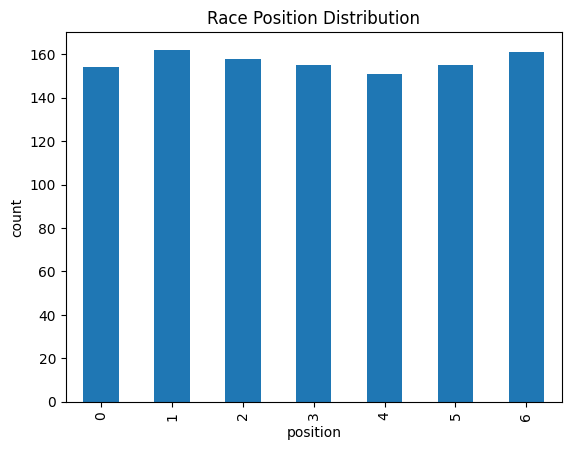

In [483]:
ud = unique_data
ud['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Race Position Distribution')
plt.xlabel('position')
plt.ylabel('count')
plt.show

This data show that there is an even distribution of all the different labels

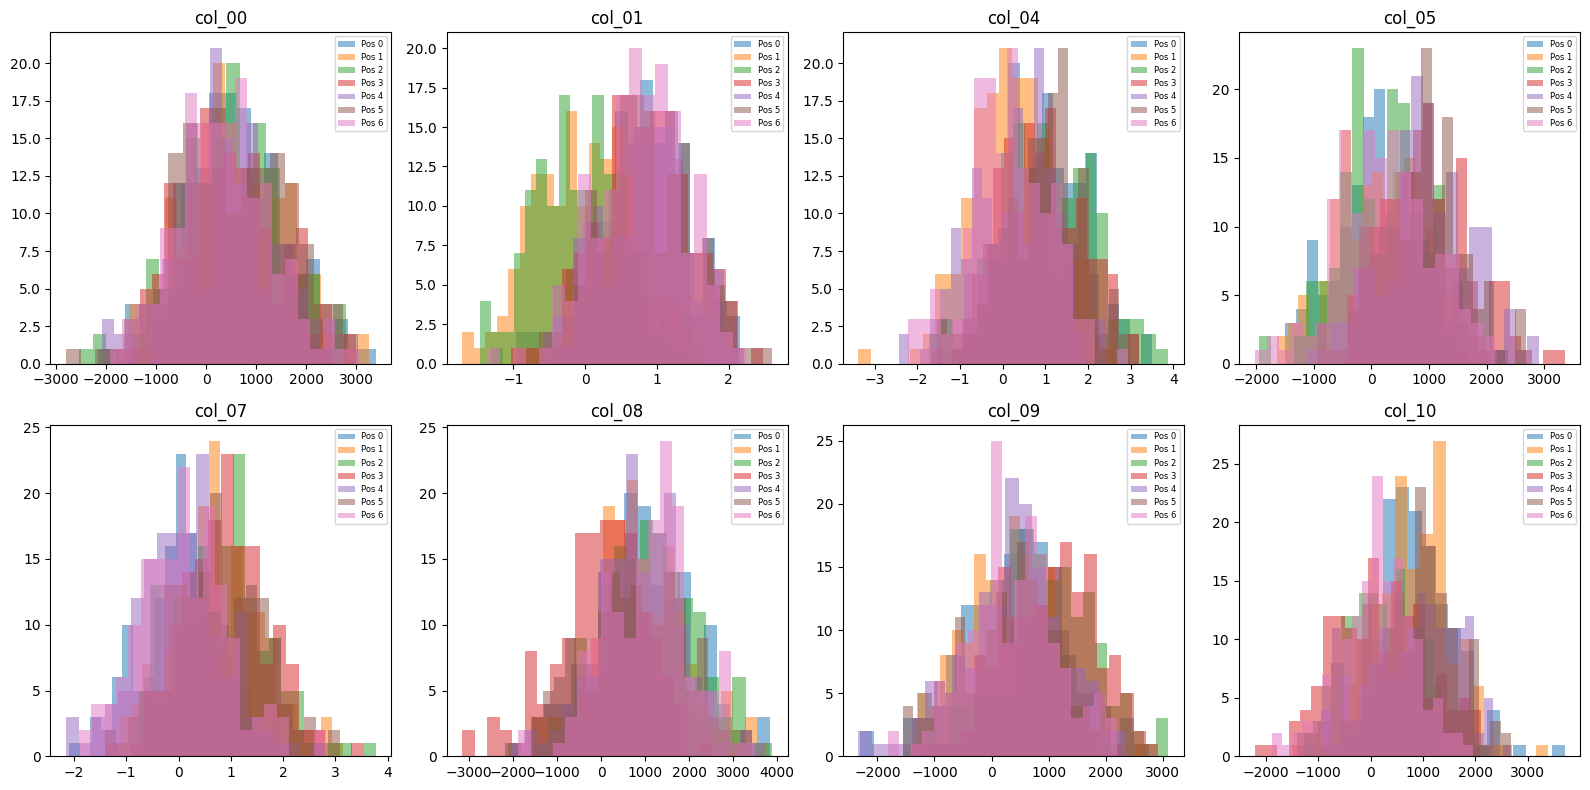

In [484]:
numeric_col = ['col_00', 'col_01', 'col_04', 'col_05', 'col_07', 'col_08', 'col_09', 'col_10', 'col_12', 'col_13']
fig, axes = plt.subplots(2, 4, figsize = (16, 8))
for ax, col in zip(axes.flatten(), numeric_col):
    for label in sorted(ud['label'].unique()):
        subset = ud[ud['label'] == label][col].dropna()
        ax.hist(subset, alpha = 0.5, label = f'Pos {label}', bins = 20)
    ax.set_title(col)
    ax.legend(fontsize = 6)
plt.tight_layout()
plt.show()

It seems like all the numeric data shows the same distribution in position.

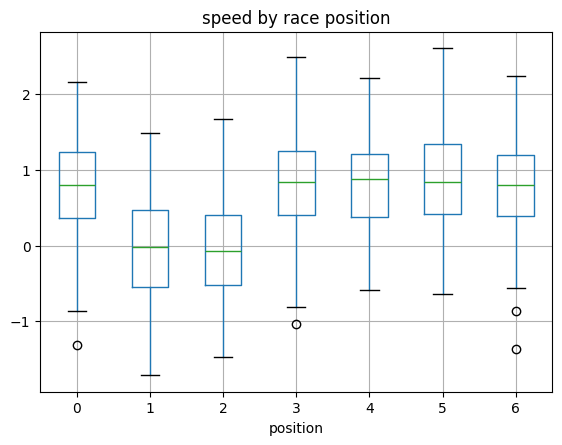

In [485]:
ud.boxplot(column = 'col_01', by = 'label')
plt.title("speed by race position")
plt.suptitle('')
plt.xlabel('position')
plt.show()

So it seems like what I though was the speed metric has no effect on the race positions which makes me feel like this data is useless.

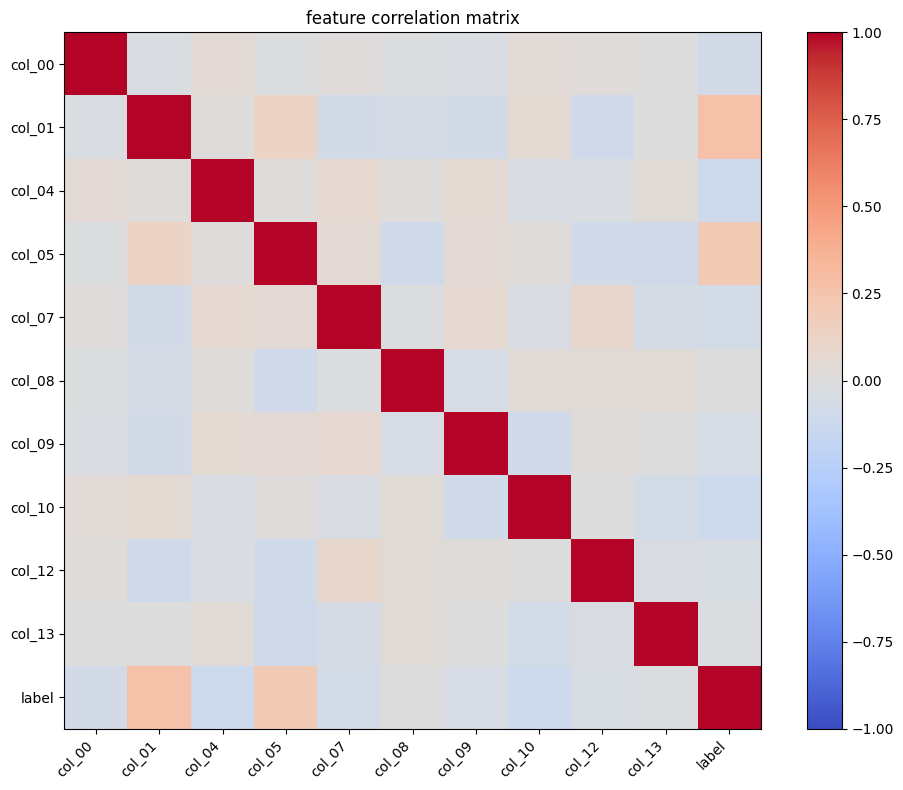

In [486]:
corr = ud[numeric_col + ['label']].corr()
fig, ax = plt.subplots(figsize = (10, 8))
im = ax.imshow(corr, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.colorbar(im)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation = 45, ha = 'right')
ax.set_yticklabels(corr.columns)
plt.title('feature correlation matrix')
plt.tight_layout()
plt.show()

Yup zero correlation show here

In [487]:
#because of this data we can remove all the numerical data as it is not correlated at all
numeric_col = ['col_00', 'col_01', 'col_04', 'col_05', 'col_06', 'col_07', 'col_08', 'col_09', 'col_10', 'col_12', 'col_13']
def drop_columns(frame, columns):
    frame = frame.drop(columns, axis = 1)
    return frame

def one_hot_encode(frame, columns):
    dummies = frame[columns].str.split(',').explode().str.strip()
    dummies = pandas.get_dummies(dummies).groupby(level = 0).max()
    frame = pandas.concat([frame.drop(columns, axis = 1), dummies], axis = 1)
    return frame

unique_data = drop_columns(unique_data, numeric_col)
unique_data = one_hot_encode(unique_data, 'col_03')
unique_data = one_hot_encode(unique_data, 'col_11')
unique_data = one_hot_encode(unique_data, 'col_14')

unique_data

,label,col_02,Badminton,Baseball,Basketball,Boxing,Football,Golf,Ice Hockey,Motor Sports,...,Computer Game Design,Computer Science,Data Science,Electrical Engineering,Games And Playable Media,Human Computer Interaction,Natural Language Processing,Robotics Engineering,Statistics,Technology And Information Management
0,2,Eriq,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1,Michael,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,Reilly,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,5,Lise,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,1,Tony,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,5,Lise,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1092,0,Fabrice,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1093,1,Michael,True,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
1094,3,Sam,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


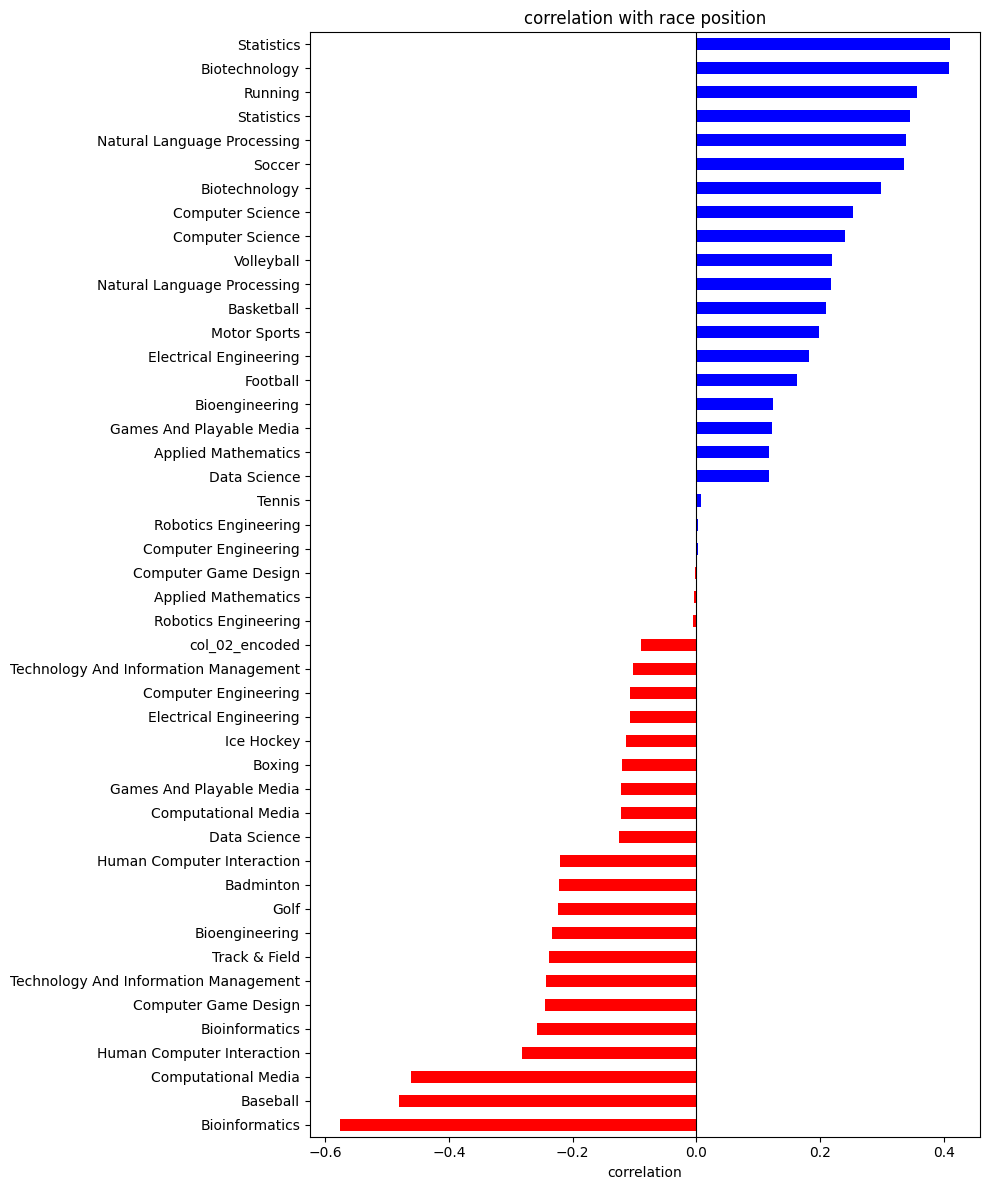

In [488]:
corr_data = unique_data.copy()
corr_data['col_02_encoded'] = pandas.factorize(corr_data['col_02'])[0]
corr_data = corr_data.drop(columns=['col_02'])
corr_data = corr_data.astype(float)

label_corr = corr_data.corr()['label'].drop('label').sort_values()
fig, ax = plt.subplots(figsize = (10, 12))
colors = ['red' if x < 0 else 'blue' for x in label_corr]
label_corr.plot(kind = 'barh', ax = ax, color = colors)
ax.axvline(x = 0, color = 'black', linewidth = 0.8)
plt.title('correlation with race position')
plt.xlabel('correlation')
plt.tight_layout()
plt.show()
unique_data['col_02_encoded'] = pandas.factorize(unique_data['col_02'])[0]
unique_data = unique_data.drop(columns=['col_02'])

So a handfull of majors and sports have a correlation with value that is worth looking at.

# Part 3: Modeling

Now that you have a good grasp of your clean data,
it is time to do some machine learning!
(Technically all our previous steps were also machine learning,
but now we get to use classifiers!)

Use the skills you developed to select **three** classifiers and implement them on your data.
For example, you can narrow down your choices to three classifiers which may include:
- Logistic regression
- K-nearest neighbors
- Decision tree
- Or others

<h4 style="color: darkorange; font-size: x-large";>★ Task 3.A</h4>

Complete the following function that takes in no parameters,
and returns a list with **three** untrained classifiers you are going to explore in this assignment.
This method may set parameters/options for the classifiers, but should not do any training/fitting.

For example, if you wanted to use logistic regression,
then **one** of your list items may be:
```
sklearn.linear_model.LogisticRegression()
```

In [489]:
def create_classifiers():
    untrained_models = [sklearn.ensemble.RandomForestClassifier(n_estimators = 200, random_state = 44),
                        sklearn.neighbors.KNeighborsClassifier(n_neighbors = 6),
                        sklearn.naive_bayes.GaussianNB()]
    return untrained_models

my_classifiers = create_classifiers()
my_classifiers

[RandomForestClassifier(n_estimators=200, random_state=44),
 KNeighborsClassifier(n_neighbors=6),
 GaussianNB()]

Now that we have some classifiers, we can see how they perform.

<h4 style="color: darkorange; font-size: x-large";>★ Task 3.B</h4>

Complete the following function that takes in an untrained classifier, a DataFrame, and a number of folds.
This function should run k-fold cross validation with the classifier and the data,
and return a list with the accuracy of each run of cross validation.
You can assume that the frame has the column `label` and the rest of the columns can be considered clean numeric features.

Note that you may have to break your frame into features and labels to do this.
Do not change the passed-in frame (make copies instead).

If you are getting any `ConvergenceWarning`s you may either ignore them,
or try and address them
(they will not affect your autograder score, but may be something to discuss in the written portion of this assignment).

In [490]:
def cross_fold_validation(classifier, frame, folds):
    ud = frame.copy()
    x = ud.drop(columns = ['label'])
    y = ud['label']
    scores = cross_val_score(classifier, x, y, cv = folds, scoring = 'accuracy')
    return list(scores)

my_classifiers_scores = []
for classifier in my_classifiers:
    accuracy_scores = cross_fold_validation(classifier, unique_data, 5)
    my_classifiers_scores.append(accuracy_scores)
    print(f"\nClassifer: {type(classifier).__name__}")
    for i, score in enumerate(accuracy_scores):
        print(f"   Fold {i+1}: {score:.4f}")
    print(f"   Mean:   {sum(accuracy_scores)/len(accuracy_scores):.4f}")
    print(f"   STD:    {numpy.std(accuracy_scores):.4f}")


Classifer: RandomForestClassifier
   Fold 1: 0.9955
   Fold 2: 0.9909
   Fold 3: 0.9909
   Fold 4: 0.9909
   Fold 5: 0.9817
   Mean:   0.9900
   STD:    0.0045

Classifer: KNeighborsClassifier
   Fold 1: 0.9818
   Fold 2: 0.9817
   Fold 3: 0.9635
   Fold 4: 0.9863
   Fold 5: 0.9680
   Mean:   0.9763
   STD:    0.0089

Classifer: GaussianNB
   Fold 1: 0.8636
   Fold 2: 0.9178
   Fold 3: 0.9498
   Fold 4: 0.8904
   Fold 5: 0.8858
   Mean:   0.9015
   STD:    0.0297


<h4 style="color: darkorange; font-size: x-large";>★ Task 3.C</h4>

Complete the following function that takes in two equally-sized lists of numbers and a p-value.
This function should compute whether there is a statistical significance between
these two lists of numbers using a [Student's t-test](https://en.wikipedia.org/wiki/Student%27s_t-test)
at the given p-value.
Return `True` if there is a statistical significance, and `False` otherwise.
Hint: If you wish, you may use the `ttest_ind()` [method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) provided in the scipy package. 

In [491]:
def significance_test(a_values, b_values, p_value):
    _, p = ttest_ind(a_values, b_values)
    return p < p_value

for i in range(len(my_classifiers)):
    for j in range(i + 1, len(my_classifiers)):
        significant = significance_test(my_classifiers_scores[i], my_classifiers_scores[j], 0.10)
        print("%s vs %s: %s" % (type(my_classifiers[i]).__name__,
                                type(my_classifiers[j]).__name__, significant))

RandomForestClassifier vs KNeighborsClassifier: True
RandomForestClassifier vs GaussianNB: True
KNeighborsClassifier vs GaussianNB: True


<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Modeling</h4>

Describe the classifiers you have chosen.
Be sure to include all details about any parameter settings used for the algorithms.

Compare the performance of your models using k-fold validation.
You may look at accuracy, F1 or other measures.

Then, briefly summarize your results.
Are your results statistically significant?
Is there a clear winner?
What do the standard deviations look like, and what do they tell us about the different models?
Include a table like Table 1.

<center>Table 1: Every table needs a caption.</center>

| Model | Mean Accuracy | Standard Deviation of Accuracy |
|-------|---------------|--------------------------------|
| Logistic Regression | 0.724 | 0.004
| K-Nearest Neighbor | 0.750 | 0.003
| Decision Tree | 0.655 | 0.011

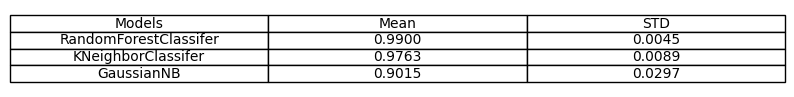

In [492]:
data = {'Models': ['RandomForestClassifer', 'KNeighborClassifer', 'GaussianNB'],
        'Mean': ['0.9900', '0.9763', '0.9015'],
        'STD': ['0.0045', '0.0089', '0.0297']}

df = pandas.DataFrame(data)
fig, ax = plt.subplots(figsize = (10, 1))
ax.axis('off')
table = ax.table(cellText = df.values, colLabels = df.columns, loc = 'center', cellLoc = 'center')
plt.show()

Table 2: The mean accuracy and standard deviation of accuracy for all three models over 5 folds. 

I used RandomForestClassifer because with all of the boolean data it would be perfect for making complex trees. I choose parameters n_estimator=200, random_state=44 after starting with a value of 50 and 10 respectivly and building up to 300 and 10 then back to 200 and 10 then changed the k value by 10s till I chose 44. This classifier had the highest mean accuracy and the lowest standard deviation of accuracy. I choose a KNN model with a k value of 6 because the data was very focused on the repeated names correlating with the label so it could be predicted by finding euclidean distance. I choose that k value because I did not want it to be too sensitive to outliers as I expected there might be some. I choose Naive Bayes classifier because I didn't think this problem would be solved with a logrithmic line or a nueral network.

# Part 4: Analysis

Now, take some time to go over your results for each classifier and try to make sense of them.
 - Why do some classifiers work better than others?
 - Would another evaluation metric work better than vanilla accuracy?
 - Is there still a problem in the data that should be fixed in data cleaning?
 - Does the statistical significance between the different classifiers make sense?
 - Are there parameters for the classifier that I can tweak to get better performance?

<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Analysis</h4>

Discuss your observations, the relationship you found, and how you applied concepts from the class to this project.
For example, you may find that some feature has the most impact in predicting your response variable or removing a feature improves the model accuracy.
Or you may observe that your training accuracy is much higher than your test accuracy and you may want to explain what issues may arise.

Some classifiers work better than others because they specialize in different type of patterns. For example logistic regression works best when the data follows a trend line similar to a logarithmic curve. Since this is a classificiation problem I percision and recall would be more telling of the models preformance then just accuracy. Some problems could be joining both columns that had major names but I was unsure if they were both majors or one was a degree or another non joinable catagory. 

# Part 5: Conclusion

<h4 style="color: darkorange; font-size: x-large";>★ Written Task: Conclusion</h4>

Briefly summarize the important results and conclusions presented in the project.
What are the important points illustrated by your work?
Are there any areas for further investigation or improvement?

The RandomForest classifier worked the best producing an accuracy score of 99% and a standard deviation of 0.0045. Some areas that I would like to investigate more of would be if I could get 100% accuracy since it is possible and if this means the tree is overfitting however the test data and the train data have little to no noise. 

<h4 style="color: darkorange; font-size: x-large";>★ Written Task: References</h4>

Include a standard bibliography with citations referring to techniques or published papers you used throughout your report (if you used any).

For example:
```
[1] Derpanopoulos, G. (n.d.). Bayesian Model Checking & Comparison.
https://georgederpa.github.io/teaching/modelChecking.html.
```

My refrences were all pervious coding experience and then python documentation. I learned matplotlib methods while working with UCSC's Sharf Lab in the genome institute. 

# Part XC: Extra Credit

So far you have used a synthetic dataset that was created just for you.
But, data science is always more interesting when you are dealing with actual data from the real world.
Therefore, you will have an opportunity for extra credit on this assignment using real-world data.

For extra credit, repeat the **written tasks** of Parts 0 through 4 with an additional dataset that you find yourself.
For the written portion of the extra credit for Part 0, include information about where you got the data and what the data represents.
You may choose any dataset that represents real data (i.e., is **not** synthetic or generated)
and is **not** [pre-packaged in scikit-learn](https://scikit-learn.org/stable/datasets.html).

Below are some of the many places you can start looking for datasets:
 - [Kaggle](https://www.kaggle.com/datasets) -- Kaggle is a website focused around machine learning competitions,
       where people compete to see who can get the best results on a dataset.
       It is very popular in the machine learning community and has thousands of datasets with descriptions.
       Make sure to read the dataset's description, as Kaggle also has synthetic datasets.
 - [data.gov](https://data.gov/) -- A portal for data from the US government.
        The US government has a lot of data, and much of it has to be available to the public by law.
        This portal contains some of the more organized data from several different government agencies.
        In general, the government has A LOT of interesting data.
        It may not always be clean (remember the CIA factbook), but it is interesting and available.
        All data here should be real-world, but make sure to read the description to verify.
 - [UCI's Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets.php) -- UC Irvine has their own data repository with a few hundred datasets on many different topics.
        Make sure to read the dataset's description, as UCI also has synthetic datasets.
 - [WHO's Global Health Observatory](https://apps.who.int/gho/data/node.home) -- The World Health Organization keeps track of many different health-related statistics for most of the countries in the world.
        All data here should be real-world, but make sure to read the description to verify.
 - [Google's Dataset Search](https://datasetsearch.research.google.com/) -- Google indexes many datasets that can be searched here.

You can even create a dataset from scratch if you find some data you like that is not already organized into a specific dataset.
The only real distinction between "data" and a "dataset" is that a dataset is organized and finite (has a fixed size).

Create a new section in your written report for this extra credit and include all the written tasks for the extra credit there.
Each written task/section that you complete for your new dataset is eligible for extra credit (so you can still receive some extra credit even if you do not complete all parts).
There is no need to submit any code for the extra credit.
If you created a new dataset, include the dataset or links to it with your submission.

I got my dataset from Kaggle it is a collection of MRI of the brain and are labeled in four catagories glioma, meningioma, pituitary, and no tumor or healthy. The model that I will create will try to classify MRIs in these four catagories. The link is https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset?resource=download 

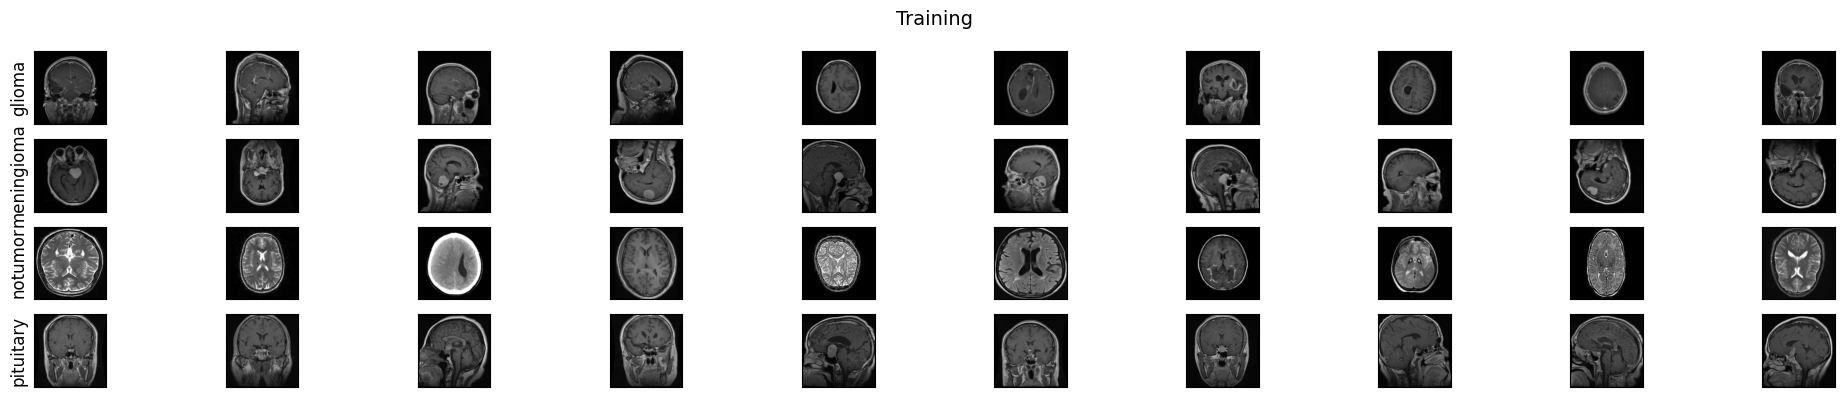

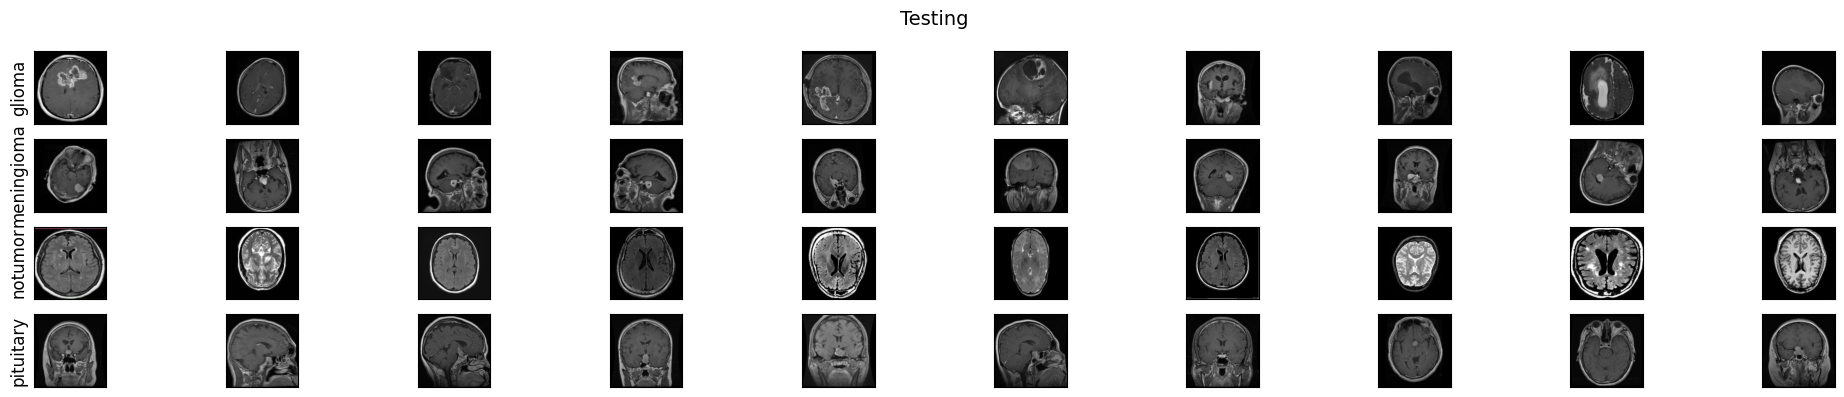

Epoch 1/2 | Train loss: 0.8122
Epoch 2/2 | Train loss: 0.4394
test accuracy: 0.800625
test loss: 0.6845676385238767
[[282  54  63   1]
 [ 69 252  70   9]
 [  7   0 392   1]
 [ 20  23   2 355]]
glioma: Precision: 0.7460 | recall 0.7050
meningioma: Precision: 0.7660 | recall 0.6300
notumor: Precision: 0.7438 | recall 0.9800
pituitary: Precision: 0.9699 | recall 0.8875


In [511]:
#first lets write little changes to our data to make the model more robust
transform = transforms.Compose([transforms.ToTensor(),
                                v2.Resize((224, 224)),
                                transforms.ColorJitter(brightness = 0.2, contrast = 0.2,),
                                transforms.GaussianBlur(kernel_size = 3),
                                transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]),
                                transforms.RandomHorizontalFlip(0.15)])

transforms_eval = transforms.Compose([transforms.ToTensor(),
                                      v2.Resize((224, 224)),
                                      transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])])

transforms_show = transforms.Compose([transforms.ToTensor(), v2.Resize((224, 224))])

# now iterate through everything and visulaize some of the data
for cat in ['Training', 'Testing']:
    dataset = datasets.ImageFolder(f"archive/{cat}", transform = transforms_show)
    class_names = dataset.classes
    fig, axes = plt.subplots(len(class_names), 10, figsize = (20, 4))
    fig.suptitle(cat, fontsize = 14)
    

    for class_idx, class_name in enumerate(class_names):
        class_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx][:10]
        for col, idx in enumerate(class_indices):
            img, _ = dataset[idx]
            ax = axes[class_idx, col]
            ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
            if col == 0:
                ax.set_ylabel(class_name, fontsize = 12)
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()

train_dataset = datasets.ImageFolder("archive/Training", transform=transform)
test_dataset  = datasets.ImageFolder("archive/Testing",  transform=transforms_eval)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
class ConvModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, 1, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1,1)
        self.conv3 = nn.Conv2d(16, 48, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0, 3)
        self.fc1 = nn.Linear(37632, 1000)
        self.fc2 = nn.Linear(1000, 4)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.flatten(start_dim =1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        output = self.fc2(x)

        return output

model = ConvModel()
Num_Epoch = 2
optimizer = optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.CrossEntropyLoss()
train_losses = []

for epoch in range(2):
    model.train()
    train_loss = 0
    train_total = 0
    for train_inputs, train_outputs in train_loader:
        train_pred = model(train_inputs)
        loss = loss_fn(train_pred, train_outputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * train_inputs.size(0)
        train_total += train_inputs.size(0)
    avg_train_loss = train_loss / train_total
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}/{Num_Epoch} | Train loss: {avg_train_loss:.4f}")

model.eval()
correct = 0
total = 0
test_loss = 0.0
alltest_labels = []
alltest_preds = []
with torch.no_grad():
    for test_inputs, test_outputs in test_loader:
        test_pred = model(test_inputs)
        loss = loss_fn(test_pred, test_outputs)
        test_loss += loss.item() * test_inputs.size(0)
        max_value, predicted = torch.max(test_pred, 1)
        total += test_outputs.size(0)
        correct += (predicted == test_outputs).sum().item()
        alltest_labels.extend(test_outputs.cpu().numpy())
        alltest_preds.extend(predicted.cpu().numpy())

test_accuracy = correct / total
avg_test_loss = test_loss / total
print(f"test accuracy: {test_accuracy}")
print(f"test loss: {avg_test_loss}")
cm = confusion_matrix(alltest_labels, alltest_preds)
vt = numpy.array(cm)
print(vt)
classes = ["glioma", "meningioma", "notumor", "pituitary"]

for i, label in enumerate(classes):
    tp = vt[i, i]
    fp = vt[:, i].sum() - tp
    fn = vt[i, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"{label}: Precision: {precision:.4f} | recall {recall:.4f}")